# Evolución de popularidad de canciones en Spotify (tiempo + países) y relación con características de audio.

In [4]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

RUTA = "universal_top_spotify_songs.csv"

In [5]:
df.columns.tolist()

['spotify_id',
 'name',
 'artists',
 'daily_rank',
 'daily_movement',
 'weekly_movement',
 'country',
 'snapshot_date',
 'popularity',
 'is_explicit',
 'duration_ms',
 'album_name',
 'album_release_date',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2110316 entries, 0 to 2110315
Data columns (total 25 columns):
 #   Column              Dtype  
---  ------              -----  
 0   spotify_id          object 
 1   name                object 
 2   artists             object 
 3   daily_rank          int64  
 4   daily_movement      int64  
 5   weekly_movement     int64  
 6   country             object 
 7   snapshot_date       object 
 8   popularity          int64  
 9   is_explicit         bool   
 10  duration_ms         int64  
 11  album_name          object 
 12  album_release_date  object 
 13  danceability        float64
 14  energy              float64
 15  key                 int64  
 16  loudness            float64
 17  mode                int64  
 18  speechiness         float64
 19  acousticness        float64
 20  instrumentalness    float64
 21  liveness            float64
 22  valence             float64
 23  tempo               float64
 24  time_signature      int6

In [9]:
df_clean = df.copy()
print("Original shape:", df_clean.shape)

Original shape: (2110316, 25)


# Eliminar duplicados exactos

In [10]:
dups = df_clean.duplicated().sum()
print("Duplicados exactos (filas idénticas):", dups)

if dups > 0:
    df_clean = df_clean.drop_duplicates()
    print("Shape tras eliminar duplicados:", df_clean.shape)


Duplicados exactos (filas idénticas): 0


# Nulos críticos

In [16]:
criticos = ["spotify_id", "snapshot_date", "country"]
df_clean = df_clean.dropna(subset=criticos)
print("Tras eliminar nulos críticos:", df_clean.shape)


Tras eliminar nulos críticos: (2080756, 25)


# Fechas a datetime

In [17]:
df_clean["snapshot_date"] = pd.to_datetime(df_clean["snapshot_date"], errors="coerce")
df_clean["album_release_date"] = pd.to_datetime(df_clean["album_release_date"], errors="coerce")
print("Fechas no convertidas:")
print({
    "snapshot_date": df_clean["snapshot_date"].isna().sum(),
    "album_release_date": df_clean["album_release_date"].isna().sum()
})


Fechas no convertidas:
{'snapshot_date': np.int64(0), 'album_release_date': np.int64(0)}


# Eliminar nulos en album_release_date

In [18]:
df_clean = df_clean.dropna(subset=["album_release_date"])
print("Shape tras eliminar nulos de album_release_date:", df_clean.shape)

Shape tras eliminar nulos de album_release_date: (2080756, 25)


# Extraer componentes temporales

In [19]:
df_clean["year"] = df_clean["snapshot_date"].dt.year
df_clean["month"] = df_clean["snapshot_date"].dt.month
df_clean["day"] = df_clean["snapshot_date"].dt.day

print("Rango de años:", int(df_clean["year"].min()), "-", int(df_clean["year"].max()))

Rango de años: 2023 - 2025


In [20]:
df_clean[["snapshot_date", "year", "month", "day"]].head(10)

,snapshot_date,year,month,day
50,2025-06-11,2025,6,11
51,2025-06-11,2025,6,11
52,2025-06-11,2025,6,11
53,2025-06-11,2025,6,11
54,2025-06-11,2025,6,11
55,2025-06-11,2025,6,11
56,2025-06-11,2025,6,11
57,2025-06-11,2025,6,11
58,2025-06-11,2025,6,11
59,2025-06-11,2025,6,11


In [22]:
print("Rango de años:", df_clean["year"].min(), "-", df_clean["year"].max())
print("Rango de meses:", df_clean["month"].min(), "-", df_clean["month"].max())
print("Rango de días:", df_clean["day"].min(), "-", df_clean["day"].max())

Rango de años: 2023 - 2025
Rango de meses: 1 - 12
Rango de días: 1 - 31


In [23]:
df_clean["year"].value_counts().sort_index()

year
2023     269397
2024    1264251
2025     547108
Name: count, dtype: int64

# Normalizar tipos de datos númericos 

In [24]:
num_cols = [
    "popularity","daily_rank","weekly_movement","duration_ms",
    "danceability","energy","loudness","valence","tempo",
    "acousticness","instrumentalness","liveness","speechiness",
    "key","mode","time_signature"
]
for col in num_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

In [25]:
df_clean[num_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 2080756 entries, 50 to 2110315
Data columns (total 16 columns):
 #   Column            Dtype  
---  ------            -----  
 0   popularity        int64  
 1   daily_rank        int64  
 2   weekly_movement   int64  
 3   duration_ms       int64  
 4   danceability      float64
 5   energy            float64
 6   loudness          float64
 7   valence           float64
 8   tempo             float64
 9   acousticness      float64
 10  instrumentalness  float64
 11  liveness          float64
 12  speechiness       float64
 13  key               int64  
 14  mode              int64  
 15  time_signature    int64  
dtypes: float64(9), int64(7)
memory usage: 269.9 MB


# Compruebo si tengo valores fuera de rango

In [26]:
check_cols = ["danceability","energy","valence","acousticness",
              "instrumentalness","liveness","speechiness"]

for c in check_cols:
    if c in df_clean.columns:
        fuera = df_clean[(df_clean[c] < 0) | (df_clean[c] > 1)]
        print(f"{c}: {len(fuera)} valores fuera de rango.")


danceability: 0 valores fuera de rango.
energy: 0 valores fuera de rango.
valence: 0 valores fuera de rango.
acousticness: 0 valores fuera de rango.
instrumentalness: 0 valores fuera de rango.
liveness: 0 valores fuera de rango.
speechiness: 0 valores fuera de rango.


# Popularidad y ranking coherentes

In [30]:
df_clean["popularity"] = df_clean["popularity"].clip(0,100)
df_clean["daily_rank"] = df_clean["daily_rank"].clip(lower=1)
print(df_clean[["popularity","daily_rank"]].describe())


         popularity    daily_rank
count  2.080756e+06  2.080756e+06
mean   7.572725e+01  2.548887e+01
std    1.574572e+01  1.442860e+01
min    0.000000e+00  1.000000e+00
25%    6.500000e+01  1.300000e+01
50%    7.900000e+01  2.500000e+01
75%    8.800000e+01  3.800000e+01
max    1.000000e+02  5.000000e+01


In [31]:
print("Popularidad – rango actual:", df_clean["popularity"].min(), "-", df_clean["popularity"].max())
print("Daily Rank – rango actual:", df_clean["daily_rank"].min(), "-", df_clean["daily_rank"].max())


Popularidad – rango actual: 0 - 100
Daily Rank – rango actual: 1 - 50


# Columna booleana is_explicit

In [33]:
df_clean["is_explicit"].dtype

dtype('bool')

In [32]:
if "is_explicit" in df_clean.columns:
    df_clean["is_explicit"] = df_clean["is_explicit"].astype(bool)
    print(df_clean["is_explicit"].value_counts(dropna=False))


is_explicit
False    1402603
True      678153
Name: count, dtype: int64


# Revisar country y normalizar

In [40]:
df_clean["country"].dtype

dtype('O')

In [37]:
df_clean["country"].unique()[:20]

array(['ZA', 'VN', 'VE', 'UY', 'US', 'UA', 'TW', 'TR', 'TH', 'SV', 'SK',
       'SG', 'SE', 'SA', 'RO', 'PY', 'PT', 'PL', 'PK', 'PH'], dtype=object)

In [38]:
df_clean["country"] = (
    df_clean["country"]
    .str.strip()
    .str.upper()    
)

In [39]:
df_clean = df_clean.dropna(subset=["country"])

In [41]:
print("Países únicos:", len(df_clean["country"].unique()))
print(df_clean["country"].value_counts().head(10))

Países únicos: 72
country
DO    29176
IT    29170
NI    29169
PL    29164
TH    29161
HN    29161
EG    29161
KZ    29161
CZ    29161
SV    29160
Name: count, dtype: int64


# Quitar columnas que no sirven

In [ ]:
drop_cols = [
    "spotify_album_image_url",
    "spotify_track_preview_url",
    "spotify_track_id",  # si ya tienes otro ID
    "spotify_album_id",
    "spotify_artist_id",
    "album_name",
    "added_by",
    "added_at",
    "snapshot_id"
]
df_clean = df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns], errors="ignore")


In [27]:
len(df_clean)

2080756

In [29]:
if "spotify_id" in df_clean.columns:
    print("Canciones únicas:", df_clean["spotify_id"].nunique())

Canciones únicas: 24967


In [43]:
df_clean.to_csv("spotify_limpio.csv", index=False)
print("spotify_limpio.csv")

spotify_limpio.csv


# Validacion final

In [44]:
print("Nulos totales restantes:")
print(df_clean.isna().sum().sort_values(ascending=False).head(10))

Nulos totales restantes:
album_name         163
name                 1
artists              0
spotify_id           0
daily_rank           0
daily_movement       0
country              0
weekly_movement      0
snapshot_date        0
popularity           0
dtype: int64


# Analisis exploratorio (eda)

In [54]:
df_clean.info()
df_clean.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
Index: 2080756 entries, 50 to 2110315
Data columns (total 28 columns):
 #   Column              Dtype         
---  ------              -----         
 0   spotify_id          object        
 1   name                object        
 2   artists             object        
 3   daily_rank          int64         
 4   daily_movement      int64         
 5   weekly_movement     int64         
 6   country             object        
 7   snapshot_date       datetime64[ns]
 8   popularity          int64         
 9   is_explicit         bool          
 10  duration_ms         int64         
 11  album_name          object        
 12  album_release_date  datetime64[ns]
 13  danceability        float64       
 14  energy              float64       
 15  key                 int64         
 16  loudness            float64       
 17  mode                int64         
 18  speechiness         float64       
 19  acousticness        float64       
 20  instru

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
spotify_id,2080756,24967,6dOtVTDdiauQNBQEDOtlAB,16301,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,2080755,21804,BIRDS OF A FEATHER,16301,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artists,2080756,13725,Billie Eilish,31457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
daily_rank,2080756.0,NaN,NaN,NaN,25.488867,1.0,13.0,25.0,38.0,50.0,14.428602
daily_movement,2080756.0,NaN,NaN,NaN,0.920995,-49.0,-1.0,0.0,2.0,49.0,7.009888
weekly_movement,2080756.0,NaN,NaN,NaN,2.923224,-49.0,-3.0,0.0,5.0,49.0,12.322942
country,2080756,72,DO,29176,NaN,NaN,NaN,NaN,NaN,NaN,NaN
snapshot_date,2080756,NaN,NaN,NaN,2024-08-08 13:40:14.701579776,2023-10-18 00:00:00,2024-03-10 00:00:00,2024-08-05 00:00:00,2025-01-08 00:00:00,2025-06-11 00:00:00,NaN
popularity,2080756.0,NaN,NaN,NaN,75.727253,0.0,65.0,79.0,88.0,100.0,15.745723
is_explicit,2080756,2,False,1402603,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# elimina problemas al graficar

In [56]:
df_clean.loc[df_clean["album_release_date"].dt.year < 1950, "album_release_date"] = pd.NaT

# distribuicion de la popularidad

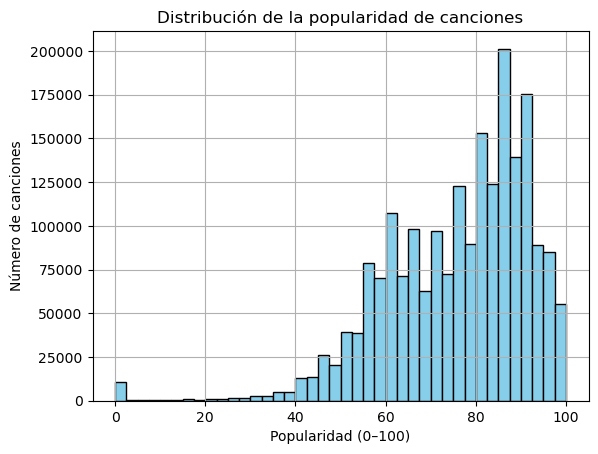

In [57]:
import matplotlib.pyplot as plt

df_clean["popularity"].hist(bins=40, color='skyblue', edgecolor='black')
plt.title("Distribución de la popularidad de canciones")
plt.xlabel("Popularidad (0–100)")
plt.ylabel("Número de canciones")
plt.show()

# ver si la popularidad ha cambiado con el tiempo

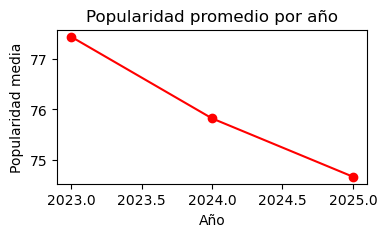

In [60]:
pop_by_year = df_clean.groupby("year")["popularity"].mean()
pop_by_year.plot(kind="line", marker="o", figsize=(4,2), color='red')
plt.title("Popularidad promedio por año")
plt.xlabel("Año")
plt.ylabel("Popularidad media")
plt.show()


# popularidad por pais 

In [63]:
pop_by_country = df_clean.groupby("country")["popularity"].mean().sort_values(ascending = False)
pop_by_country.head(10)

country
AU    87.537739
NZ    86.820668
CA    86.714999
US    86.694704
AE    86.435971
GB    86.366400
IE    85.832376
GT    85.131941
SG    84.826457
HN    84.539110
Name: popularity, dtype: float64

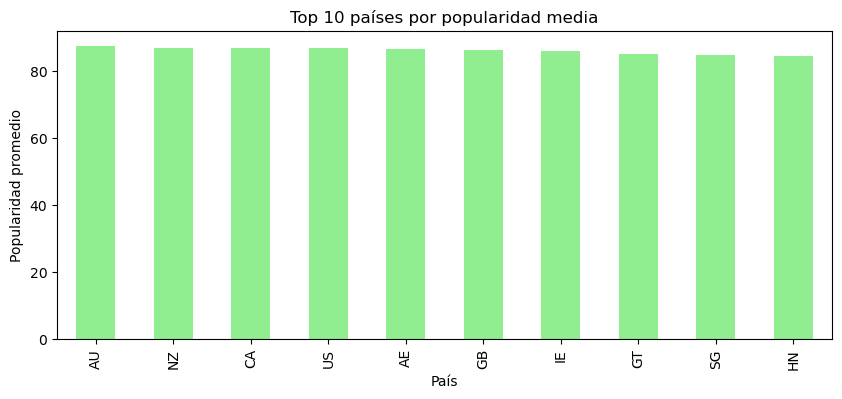

In [66]:
pop_by_country.head(10).plot(kind='bar', color='lightgreen', figsize=(10,4))
plt.title("Top 10 países por popularidad media")
plt.xlabel("País")
plt.ylabel("Popularidad promedio")
plt.show()

In [9]:
#conclusiones que saco
#una homogeneidad casi total
#globalización del consumo musical en plataformas digitales.
#Las diferencias entre mercados parecen estar más en el orden de aparición o la duración en el ranking, no en el nivel de éxito.

# Características de audio y popularidad

In [67]:
features = ["danceability","energy","valence","acousticness","instrumentalness","speechiness","liveness"]
corr = df_clean[["popularity"] + features].corr()
corr["popularity"].sort_values(ascending=False)

popularity          1.000000
instrumentalness    0.047500
energy             -0.023079
valence            -0.025759
liveness           -0.042467
danceability       -0.052074
acousticness       -0.063797
speechiness        -0.146666
Name: popularity, dtype: float64

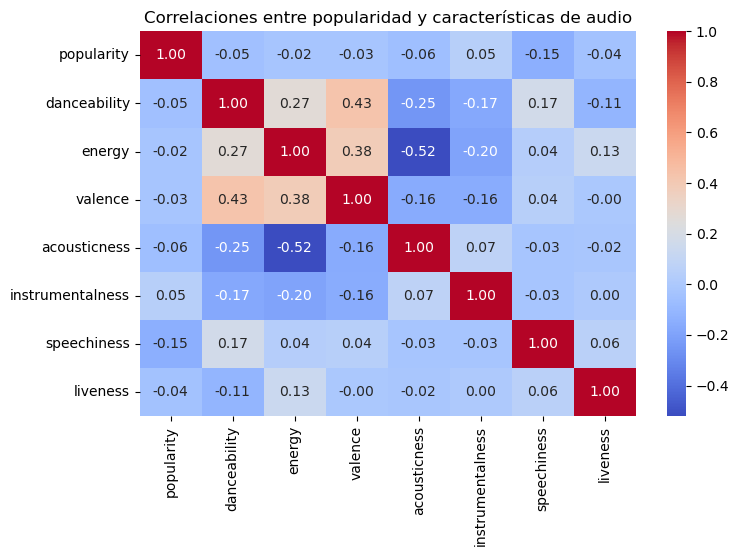

In [68]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlaciones entre popularidad y características de audio")
plt.show()


# explicitas vs no explicitas

In [72]:
df_clean.groupby("is_explicit")["popularity"].mean()

is_explicit
False    74.655599
True     77.943724
Name: popularity, dtype: float64

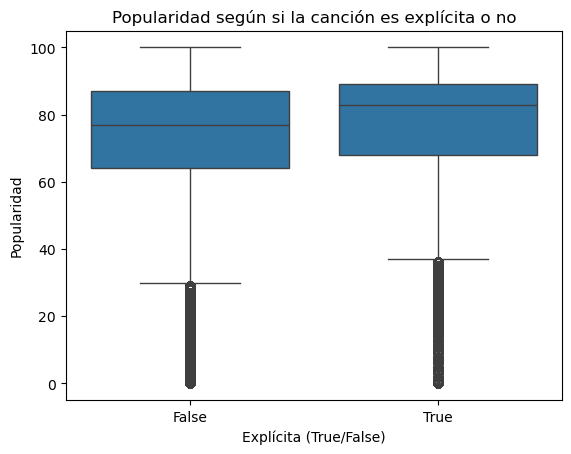

In [73]:
sns.boxplot(data=df_clean, x="is_explicit", y="popularity")
plt.title("Popularidad según si la canción es explícita o no")
plt.xlabel("Explícita (True/False)")
plt.ylabel("Popularidad")
plt.show()


# relacion entre popularidad y ranking

In [74]:
df_clean[["popularity","daily_rank"]].corr()


,popularity,daily_rank
popularity,1.000000,-0.108864
daily_rank,-0.108864,1.000000


In [ ]:
#“La correlación entre popularidad y ranking es débilmente negativa (–0.11).
#Esto indica que, aunque las canciones mejor posicionadas suelen tener mayor popularidad, el ranking diario por país y la popularidad global de Spotify no siempre coinciden.
#Es decir, el éxito local no garantiza un puntaje global alto.”

# exportar para power bi

In [77]:
cols_export = ["name","artists","country","year","popularity","danceability","energy","valence","is_explicit"]
df_clean[cols_export].to_csv("spotify_limpio_neoland.csv", index=False)


In [3]:
import pandas as pd

df_clean = pd.read_csv("spotify_limpio.csv")

In [4]:
summary = {
    "total_filas": len(df_clean),
    "canciones_unicas": df_clean["spotify_id"].nunique(),
    "paises_unicos": df_clean["country"].nunique(),
    "popularidad_media": round(df_clean["popularity"].mean(), 2)
}

print(summary)


{'total_filas': 2080756, 'canciones_unicas': 24967, 'paises_unicos': 72, 'popularidad_media': np.float64(75.73)}


In [11]:
pop_by_country = (
    df_clean.groupby("country", as_index=False)["popularity"]
            .mean()
            .rename(columns={"popularity": "popularity_mean"})
)
pop_by_country.to_csv("pop_by_country.csv", index=False)


In [6]:
pop_country_year = (
    df_clean.groupby(["country", "year"], as_index=False)["popularity"]
            .mean()
            .rename(columns={"popularity": "popularity_mean"})
)
pop_country_year.to_csv("pop_by_country_year.csv", index=False)


In [7]:
cols_keep = [
    "spotify_id", "name", "artists", "country", "year", "popularity", "is_explicit",
    "danceability", "energy", "valence", "acousticness", "instrumentalness", "tempo"
]

df_subset = df_clean[cols_keep].copy()
df_subset.to_csv("spotify_dataset_reducido.csv", index=False)


In [21]:
pop_by_country = (
    df_clean.groupby("country", as_index=False)["popularity"]
            .mean()
            .rename(columns={"popularity": "popularity_mean"})
)
pop_by_country.sort_values(by="popularity_mean")


,country,popularity_mean
34,IS,58.500069
20,EG,60.096190
5,BG,61.136112
42,MA,61.972013
22,FI,62.456893
...,...,...
0,AE,86.435971
67,US,86.694704
9,CA,86.714999
49,NZ,86.820668
